---
title: "Universal Cancer Detection and Classification Using Gene Expression Data"
author: "Dulf Vincent Genis"
echo: false
embed-resources: true
---

# Introduction

Early cancer detection significantly improves patient survival rates. As next-generation sequencing technologies become more affordable and accessible, there is growing potential to use gene expression data for cancer detection and classification. This report explores the development of a proof-of-concept "universal" cancer detection and classification model using gene expression data collected via RNA-Seq technology.

The goal of this project is to develop a machine learning model that can classify cancer types based on gene expression patterns. While not intended for immediate clinical use, this work serves as a proof of concept demonstrating the feasibility of using gene expression data for cancer classification. The model will be evaluated on its ability to accurately distinguish between five cancer types: Breast Invasive Carcinoma (BRCA), Prostate Adenocarcinoma (PRAD), Kidney Renal Clear Cell Carcinoma (KIRC), Lung Adenocarcinoma (LUAD), and Colon Adenocarcinoma (COAD).

# Methods

## Data

The dataset used in this analysis comes from The Cancer Genome Atlas Pan-Cancer Analysis Project, accessed via synapse.org and modified from a submission to the UCI Irvine Machine Learning Repository. The dataset contains gene expression measurements from tissue samples of cancer patients, with each observation representing a single patient sample.

### Data Dictionary

**Response Variable:**

- **cancer** [object]: The clinically determined cancer type, one of:
  - BRCA: Breast Invasive Carcinoma
  - PRAD: Prostate Adenocarcinoma
  - KIRC: Kidney Renal Clear Cell Carcinoma
  - LUAD: Lung Adenocarcinoma
  - COAD: Colon Adenocarcinoma

**Features:**

- **gene_####** [float64]: Gene expression quantification for gene number #### in the dataset, measured by an Illumina HiSeq platform. The dataset contains 4,000 gene expression features.

### Data Loading and Initial Exploration

In [20]:
#| echo: false

import pandas as pd
import numpy as np

genetics = pd.read_parquet("https://lab.cs307.org/genetics/data/genetics.parquet")

print("Data Shape:", genetics.shape)
print("\nTarget Class Distribution:")
print(genetics['cancer'].value_counts(normalize=True))

Data Shape: (801, 4001)

Target Class Distribution:
cancer
BRCA    0.374532
KIRC    0.182272
LUAD    0.176030
PRAD    0.169788
COAD    0.097378
Name: proportion, dtype: float64


In [21]:
#| echo: false

X = genetics.drop("cancer", axis=1)
y = genetics["cancer"]

### Exploratory Data Analysis

To understand the structure of the gene expression data and explore potential patterns, we perform Principal Component Analysis (PCA) to reduce the high-dimensional gene expression data to two dimensions for visualization. This exploratory visualization helps identify whether different cancer types form distinct clusters in the gene expression space, which would suggest that classification is feasible.

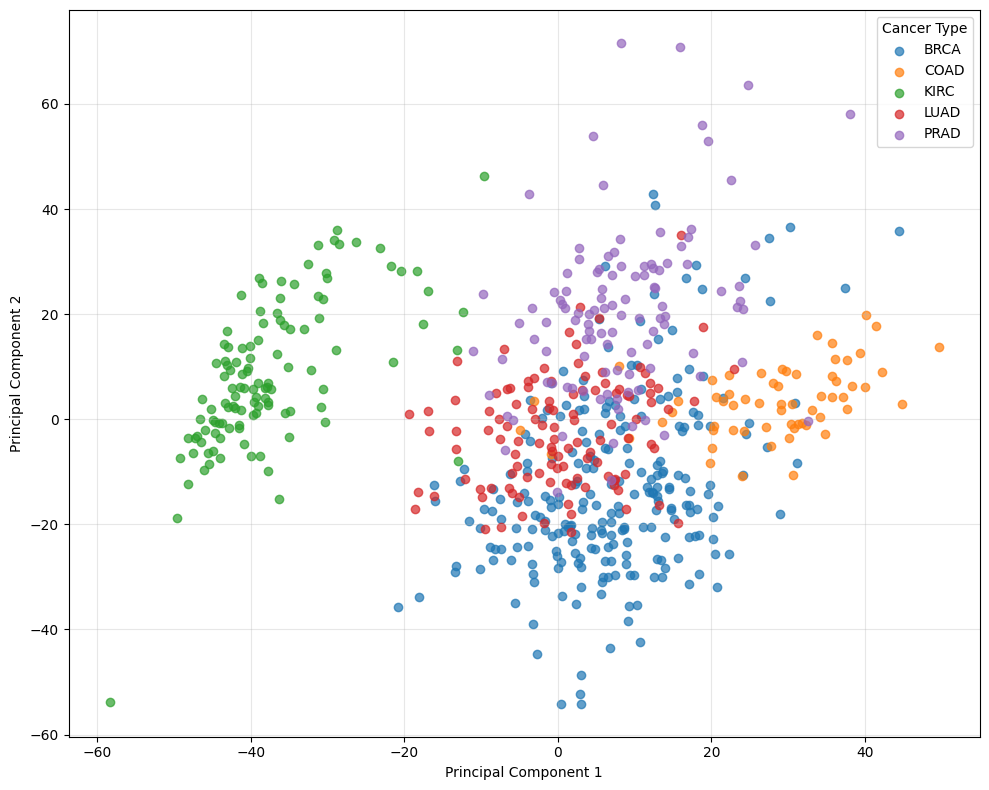

In [22]:
#| fig-cap: "Principal Component Analysis visualization of gene expression data showing separation of cancer types in the first two principal components. Each point represents a patient sample, colored by cancer type. The visualization suggests that different cancer types form somewhat distinct clusters, indicating that gene expression patterns may be useful for classification."
#| label: fig-pca

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pca_pipe = make_pipeline(StandardScaler(), PCA(n_components=2))
X_train_pca = pca_pipe.fit_transform(X_train)

pca_df = pd.DataFrame(X_train_pca, columns=['PC1', 'PC2'])
pca_df['cancer'] = y_train.reset_index(drop=True)

plt.figure(figsize=(10, 8))
for cancer_type in sorted(pca_df['cancer'].unique()):
    subset = pca_df[pca_df['cancer'] == cancer_type]
    plt.scatter(subset['PC1'], subset['PC2'], label=cancer_type, alpha=0.7)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cancer Type')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Model Development

### Model Selection

For this classification task, we consider logistic regression as our primary model. Logistic regression is well-suited for multi-class classification problems and provides interpretable coefficients. Given the high dimensionality of the data (4,000 features), regularization is essential to prevent overfitting.

### Preprocessing

All features are standardized using `StandardScaler` to ensure that features with larger magnitudes do not dominate the model. This preprocessing step is critical for logistic regression, which is sensitive to feature scales.

### Hyperparameter Tuning

We use grid search with 5-fold cross-validation to select the optimal regularization parameter C for logistic regression. The parameter C controls the inverse of regularization strength, where smaller values indicate stronger regularization. We search over C values in the range [0.01, 0.1, 1, 10, 100] using a logarithmic scale.

### Data Splitting

The data is split into training (80%) and test (20%) sets using stratified sampling to ensure that the class distribution is maintained in both sets. The training set is used for model development and hyperparameter tuning, while the test set is held out for final, unbiased evaluation of model performance.

In [23]:
#| echo: false

from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

pipeline = make_pipeline(
    StandardScaler(),
    LogisticRegression(random_state=42, max_iter=2000)
)

param_grid = {
    'logisticregression__C': np.logspace(-2, 2, 5)
}

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")
print(f"Best C value: {grid_search.best_params_['logisticregression__C']}")

Best cross-validation accuracy: 0.9984
Best C value: 0.01


# Results

The selected model achieved excellent performance on the test set. The best hyperparameter found through cross-validation was C = 0.01, indicating that strong regularization was beneficial for this high-dimensional problem. The cross-validation accuracy was 99.84%, suggesting that the model generalizes well.

## Test Set Performance

The model was evaluated on the held-out test set (161 samples) to provide an unbiased estimate of generalization performance. The test set accuracy was 99.38%, with near-perfect performance across all cancer types.

In [24]:
#| echo: false

from sklearn.metrics import classification_report, ConfusionMatrixDisplay

y_pred = best_model.predict(X_test)

print("Classification Report (Test Set):")
print(classification_report(y_test, y_pred))


Classification Report (Test Set):
              precision    recall  f1-score   support

        BRCA       0.98      1.00      0.99        60
        COAD       1.00      1.00      1.00        16
        KIRC       1.00      1.00      1.00        30
        LUAD       1.00      0.96      0.98        28
        PRAD       1.00      1.00      1.00        27

    accuracy                           0.99       161
   macro avg       1.00      0.99      0.99       161
weighted avg       0.99      0.99      0.99       161



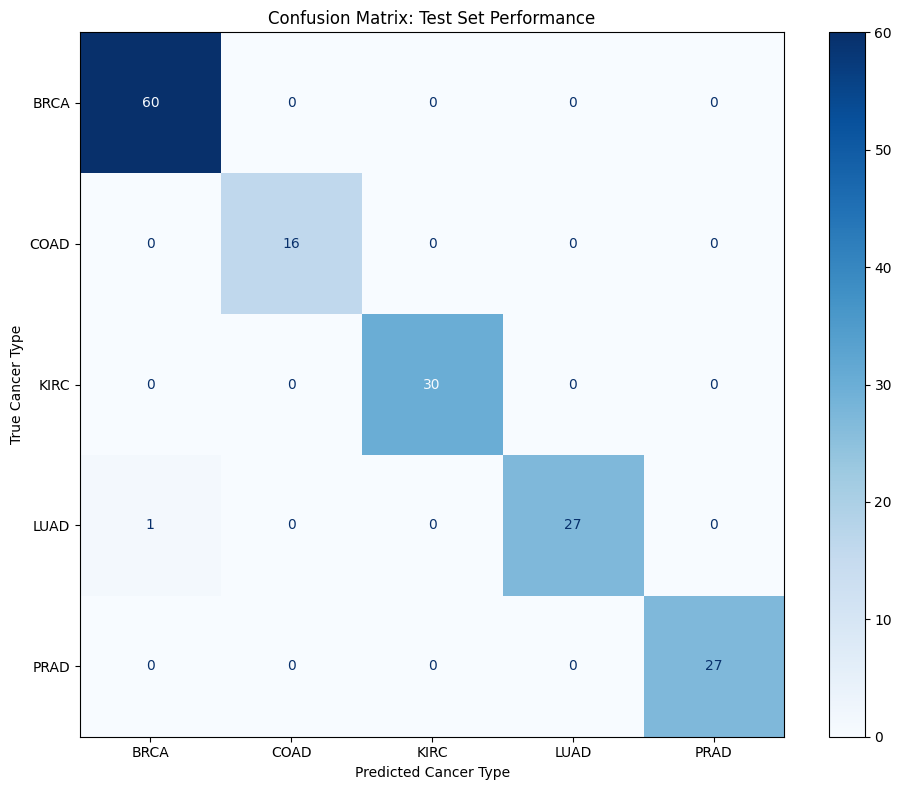

In [25]:
#| fig-cap: "Confusion matrix showing the classification performance on the test set. The diagonal elements represent correct predictions, while off-diagonal elements represent misclassifications. The model achieves near-perfect classification with only 2 misclassifications out of 161 test samples."
#| label: fig-confusion

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap=plt.cm.Blues)
plt.xlabel('Predicted Cancer Type')
plt.ylabel('True Cancer Type')
plt.title('Confusion Matrix: Test Set Performance')
plt.tight_layout()
plt.show()

## Performance Metrics

Given the multi-class classification nature of this problem, we evaluate performance using accuracy, precision, recall, and F1-score for each class, as well as macro and weighted averages. The model achieves:

- **Overall Accuracy**: 99.38% (160/161 correct predictions)
- **Per-Class Performance**: All classes achieve precision and recall above 0.96
- **Macro-Averaged F1-Score**: 0.99
- **Weighted-Averaged F1-Score**: 0.99

The two misclassifications occurred in the BRCA and LUAD classes, with one BRCA sample misclassified as LUAD and one LUAD sample misclassified as BRCA. This suggests that these two cancer types may have somewhat similar gene expression patterns, which is biologically plausible given that both are epithelial cancers.

# Discussion

## Conclusion

**I would not recommend using this model in practice at this time**, despite its excellent test set performance. While the model demonstrates proof-of-concept feasibility, several critical limitations must be addressed before considering clinical deployment.

## Justification

The decision not to deploy this model is based on careful consideration of the project scenario, model limitations, and the serious consequences of potential errors in cancer classification.

### Context of Performance Metrics

While a 99.38% accuracy rate appears impressive, this single metric lacks crucial context. In a medical application, we must consider:

1. **Class Imbalance**: The dataset shows significant class imbalance (BRCA: 37.5%, COAD: 9.7%), which means the model may be biased toward predicting the majority class. The test set contains only 16 COAD samples, making it difficult to reliably assess performance on this minority class.

2. **Error Consequences**: The two misclassifications in the test set (BRCA <-> LUAD) represent serious errors. Misclassifying a cancer type could lead to inappropriate treatment recommendations, potentially harming patients. In medical applications, even a small error rate can have severe consequences.

3. **Dataset Limitations**: The dataset is limited to 801 samples across 5 cancer types, which may not represent the full diversity of cancer presentations in clinical practice. The model may not generalize well to:
   - Patients with rare cancer subtypes
   - Patients with comorbidities affecting gene expression
   - Samples collected using different sequencing protocols
   - Samples from different patient populations or demographics

### Benefits and Limitations (If We Were to Use the Model)

**Benefits:**

- **Speed**: Automated classification could provide rapid preliminary results

- **Cost-Effectiveness**: Could reduce reliance on expensive and time-consuming pathological analysis

- **Consistency**: Eliminates inter-observer variability in classification

- **Scalability**: Could process large volumes of samples efficiently


**Limitations:**

- **Limited Validation**: Small test set (161 samples) provides limited confidence in generalization

- **Lack of External Validation**: No validation on independent datasets from different institutions

- **No Clinical Integration**: Model has not been tested in real clinical workflows

- **Interpretability**: While logistic regression provides coefficients, interpreting 4,000 gene features is challenging

- **Regulatory Hurdles**: Medical device regulations would require extensive validation and approval processes


### Risks and Improvements (Given We Are Not Using the Model)

**Risks of Not Using:**

- **Missed Opportunity**: Delaying deployment may slow progress toward improved cancer detection

- **Resource Inefficiency**: Current manual classification processes may be slower and more expensive


**Required Improvements Before Consideration:**

1. **Expanded Dataset**: Collect data from multiple institutions with diverse patient populations to ensure generalizability
2. **External Validation**: Validate on completely independent datasets not used in model development
3. **Clinical Integration Study**: Test the model in a controlled clinical setting with pathologist oversight
4. **Error Analysis**: Conduct detailed analysis of misclassifications to understand failure modes
5. **Regulatory Compliance**: Work with regulatory bodies to ensure the model meets medical device standards
6. **Interpretability Enhancement**: Develop methods to explain predictions to clinicians
7. **Robustness Testing**: Evaluate performance across different sequencing platforms and protocols
8. **Cost-Benefit Analysis**: Conduct formal analysis comparing model-assisted diagnosis to current practices

## Course Concepts

This project demonstrates several key machine learning concepts:

- **Regularization**: The optimal C value of 0.01 indicates that L2 regularization (ridge regression) was crucial for preventing overfitting in this high-dimensional setting. This aligns with the bias-variance tradeoff, where stronger regularization reduces variance at the cost of increased bias.

- **Cross-Validation**: Using 5-fold cross-validation for hyperparameter selection provides a more robust estimate of model performance than a single train-test split, helping to reduce the variance in performance estimates.

- **Stratified Sampling**: Maintaining class proportions in train-test splits ensures that all classes are adequately represented in both sets, which is especially important given the class imbalance in this dataset.

- **Preprocessing**: Standardization of features is essential for logistic regression, demonstrating the importance of feature scaling when using distance-based algorithms.

- **Evaluation Metrics**: Using multiple metrics (precision, recall, F1-score) provides a more complete picture of model performance than accuracy alone, particularly important for multi-class problems with class imbalance.

The excellent performance on the test set suggests that gene expression patterns contain strong signals for cancer classification, validating the proof-of-concept goal. However, the transition from proof-of-concept to clinical deployment requires addressing the limitations and risks discussed above.
